## 🗃 Load and Transform

In [140]:
import pandas as pd
import time

pd.set_option('future.no_silent_downcasting',True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = "C:/Users/Acer/Downloads/original_customer_data.csv"
start = time.time()
df = pd.read_csv(path)
print(f"✅ File '{path.rpartition('/')[2]}' loaded in {round(time.time() - start, 2)} secs!")

✅ File 'original_customer_data.csv' loaded in 0.17 secs!


### 👨‍👨‍👧‍👧 Age Range

In [141]:
bin_years = 10

min_age = df['Age'].min()
max_age = df['Age'].max()

print(f'Min age = {min_age}\nMax age = {max_age}')

bins = list(range(0, int(max_age) + bin_years + 1, bin_years))
bins = [b for b in bins if b >= (min_age // bin_years) * bin_years]

# forces first bin = min_age, and last = max_rangef
bins[0] = int(min_age)
bins[-1] = int(max_age)

bins_arr = np.array(bins)

starts = bins_arr[:-1].copy()
starts[1:] += 1
ends = bins_arr[1:]

bin_labels = [f"{s}-{e}" for s, e in zip(starts, ends)]

# pd.cut() must take include_lowest = True to not exclude very first val (min_range)
df['Age_Range'] = pd.cut(df['Age'], bins= bins,
                         labels= bin_labels,
                         include_lowest = True)

counts = df['Age_Range'].value_counts(dropna=False)
pct = round(df['Age_Range'].value_counts(normalize=True) * 100, 2)

age_summary= pd.concat([counts, pct], axis = 1)
age_summary.columns = ['Total Count', 'Pct']

print(age_summary)

Min age = 18
Max age = 85
           Total Count    Pct
Age_Range                    
31-40             1229  19.15
51-60             1194  18.60
41-50             1165  18.15
21-30             1091  17.00
61-70              876  13.65
71-80              560   8.73
18-20              204   3.18
81-85               99   1.54


### 💰 Understanding Monetary Columns
- Since ```Total_Revenue = (Total_Charges + Total_Long_Distance_Charges + Total_Extra_Data_Charges) - Total_Refunds```, a new calculated column was created - ```Monthly_Avg```.

In [142]:
import numpy as np

calculated_revenue = (
    df['Total_Charges'] + 
    df['Total_Long_Distance_Charges'] + 
    df['Total_Extra_Data_Charges'] - 
    df['Total_Refunds']
)

# Will all values in 'Total_Revenue' match the func?
all_match = np.isclose(calculated_revenue, df['Total_Revenue']).all()

if all_match:
    print("Function is correct! Creating 'Monthly_Avg' col with Revenue/Tenure.\n")
    df['Monthly_Avg'] = round(df['Total_Revenue'] / df['Tenure_in_Months'], 2)
    print(df[['Total_Revenue', 'Tenure_in_Months', 'Monthly_Avg']].head()) 
else:
    print("Function doesn't match!")

Function is correct! Creating 'Monthly_Avg' col with Revenue/Tenure.

   Total_Revenue  Tenure_in_Months  Monthly_Avg
0         974.81                27        36.10
1         610.28                13        46.94
2         415.45                35        11.87
3        1599.51                21        76.17
4         289.54                 8        36.19


### 🔎 Filling service-related nulls with 'No'

In [143]:
no_phone = df['Phone_Service'] == 'No'
null_multi = df['Multiple_Lines'].isna()

if (no_phone & ~null_multi).sum() == 0:
    print(f"\u2713 The {no_phone.sum()} 'No' rows for Phone_Service match the nulls of Multiple_Lines. Altering those nulls to 'No':")
    df.loc[null_multi, 'Multiple_Lines'] = 'No'
    print(df['Multiple_Lines'].value_counts(dropna = False))
    print("-" * 60)

has_nulls = df.isna().any().drop(['Value_Deal', 'Multiple_Lines', 'Phone_Service', 'Churn_Category', 'Churn_Reason']).copy()
internet_related = has_nulls[has_nulls]

no_internet = df['Internet_Service'] =='No'

for i in internet_related.index.tolist():
    null_values = df[i].isna()
    if (null_values & ~no_internet).sum() == 0:
        print(f"\u2713 The {no_internet.sum()} 'No' rows of Internet_Service match the nulls of {i}. Altering those nulls to 'No': ")
        df.loc[null_values, i] = 'No'
        print(df[i].value_counts(dropna = False))
        print("-" * 60)

✓ The 622 'No' rows for Phone_Service match the nulls of Multiple_Lines. Altering those nulls to 'No':
Multiple_Lines
No     3704
Yes    2714
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Internet_Type. Altering those nulls to 'No': 
Internet_Type
Fiber Optic    2764
DSL            1502
No             1390
Cable           762
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Online_Security. Altering those nulls to 'No': 
Online_Security
No     4594
Yes    1824
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' rows of Internet_Service match the nulls of Online_Backup. Altering those nulls to 'No': 
Online_Backup
No     4210
Yes    2208
Name: count, dtype: int64
------------------------------------------------------------
✓ The 1390 'No' ro

### 🚩 Oultier dealing (Tukey)

- ```Total_Extra_Data_Charges``` and ```Total_Refunds``` are mostly populated by 0, so using the median replaces all values (considered as outliers) with 0.
- ```Total_Revenue``` and ```Total_Long_Distance_Charges``` tallied 19 and 193 outliers respec., and had the median replacement.

In [144]:
num_cols = df.select_dtypes(include = [np.number]).columns.to_list()
num_cols = [i for i in num_cols if i not in ('Total_Extra_Data_Charges', 'Total_Refunds')]

og_outliers = {}
outliers = {}
medians = {}
for i in num_cols:
    q1 = df[i].quantile(.25)
    q3 = df[i].quantile(.75)

    IQR = q3 - q1

    sup = q3 + 1.5 * IQR
    inf = q1 - 1.5 * IQR

    mask = (df[i] > sup) | (df[i] < inf)
    og_outliers[i] = df[mask].index.tolist()
    
    median = df[i].median() # returns float per default
    if pd.api.types.is_integer_dtype(df[i].dtype):
        median = int(round(median))
    else:
        median = median
        
    medians[i] = median 

    df.loc[mask, i] = median
    mask_updated = (df[i] > sup) | (df[i] < inf)
    
    outliers[i] = df[mask_updated].index.tolist()

medians_df = pd.DataFrame.from_dict({
    "Column": medians.keys(),
    "Col_dtype": [df[i].dtype for i in medians.keys()],
    "Median": medians.values(),
    "Median_dtype": [type(v).__name__ for v in medians.values()]
    })

og_outliers_df = pd.DataFrame.from_dict(
    {"Column": og_outliers.keys(),
     "Outlier_Count": [len(v) for v in og_outliers.values()],
     "Outlier_%": [len(v)/len(df)*100 for v in og_outliers.values()]
     #,"Outlier_indices": outliers.values()
    })

# Mask slices the df to show only outliers. Each column becomes a dict key, and its' values are the indices for each outlier.
outlier_df = pd.DataFrame.from_dict(
    {"Column": outliers.keys(),
     "Outlier_Count": [len(v) for v in outliers.values()],
     "Outlier_%": [len(v)/len(df)*100 for v in outliers.values()]
     #,"Outlier_indices": outliers.values()
    })

print("🔍 Median info for selected columns:")
print(medians_df)
print("=" * 65)
print("🚩 Original outlier detection:")
print(og_outliers_df.sort_values('Outlier_%', ascending = False))
print("=" * 57)
print("✅ Updated outlier detection:")
print(outlier_df.sort_values('Outlier_%', ascending = False))

🔍 Median info for selected columns:
                        Column Col_dtype    Median Median_dtype
0                          Age     int64    46.000          int
1          Number_of_Referrals     int64     7.000          int
2             Tenure_in_Months     int64    16.000          int
3               Monthly_Charge   float64    70.100      float64
4                Total_Charges   float64  1396.125      float64
5  Total_Long_Distance_Charges   float64   407.475      float64
6                Total_Revenue   float64  2108.635      float64
7                  Monthly_Avg   float64   138.045      float64
🚩 Original outlier detection:
                        Column  Outlier_Count  Outlier_%
7                  Monthly_Avg            681  10.610782
5  Total_Long_Distance_Charges            193   3.007167
6                Total_Revenue             19   0.296042
0                          Age              0   0.000000
1          Number_of_Referrals              0   0.000000
2             Te

### 🔢 Scale numericals
- Resistant to remaining outliers, no distortion on distances (unlike Min/Max and StandardScaler, easily skewed). The best match for KMedoids.
- Standard Scaler for KPrototypes

In [145]:
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

famd_columns = ['Contract', 'Monthly_Avg', 'Tenure_in_Months', 'Internet_Type']

data = df[famd_columns].copy()

data['Monthly_Avg'] = np.log1p(data['Monthly_Avg'])

num_cols = data.select_dtypes(include = [np.number]).columns
                   
#scaler = RobustScaler()
scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

for i in num_cols:
    print("🤖 ✔ Numerical (originally {}) data scaled for {}!".format(df[i].dtype, i))

print(f"FAMD columns: {data.columns.tolist()}") 

🤖 ✔ Numerical (originally float64) data scaled for Monthly_Avg!
🤖 ✔ Numerical (originally int64) data scaled for Tenure_in_Months!
FAMD columns: ['Contract', 'Monthly_Avg', 'Tenure_in_Months', 'Internet_Type']


## ⚙ Clustering

### 🥪 FAMD (Factor Analysis of Mixed Data) 

#### Contributions

Expected average contribution cutoff: 25.00%
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              1.528        21.82%                     21.82%
1              1.211        17.31%                     39.13%
2              1.031        14.73%                     53.86%
3              1.011        14.44%                     68.30%
4              0.969        13.84%                     82.14%
5              0.905        12.93%                     95.07%


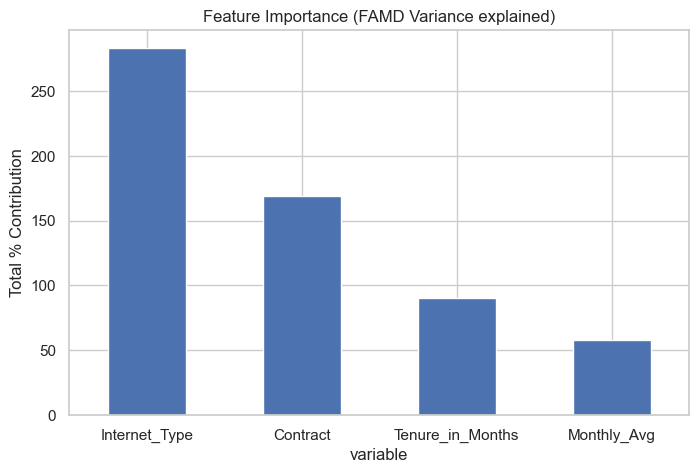

In [146]:
import prince
import matplotlib.pyplot as plt
import seaborn as sns

n_dim = 6

famd = prince.FAMD(
    n_components = n_dim,
    n_iter = 15,
    copy = True,
    check_input = True,
    random_state = 42)
famd.fit(data)

contr = famd.column_contributions_ * 100
dim0 = contr[0]
dim1 = contr[1]
dim2 = contr[2]

dim0_pct = (dim0/dim0.sum()) * 100
dim1_pct = (dim1/dim1.sum()) * 100
dim2_pct = (dim2/dim2.sum()) * 100

#print(dim0_pct.sort_values(ascending = False))

threshold = 100/len(contr)

print("Expected average contribution cutoff: {:.2f}%".format(threshold))

print(famd.eigenvalues_summary)

contr = famd.column_contributions_.sum(axis = 1).sort_values(ascending = False)

plt.figure(figsize = (8,5))
(contr * 100).plot(kind='bar')
plt.title('Feature Importance (FAMD Variance explained)')
plt.ylabel('Total % Contribution')
plt.xticks(rotation=0)
plt.show()

### K-Prototypes
- Isolated clusters worse than K-Medoids, even with high γ.

### K-Medoids

#### Elbow plot
- Total_Revenue is directly related to Monthly_Charge. The inclusion of Tenure increased variance, and allows Survivability Analysis approachs to show differences. 
- Opted cluster number: 5

#### Clustering and Metrics

In [149]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn_extra.cluster import KMedoids
import time

x_cluster = famd.row_coordinates(data).iloc[:, :6]

print("🔬 Starting K-Medoids...\n")
start2 = time.time()
k = 5
kmedoids = KMedoids(n_clusters=k, metric='euclidean', method = 'pam', random_state=0)

df['Clusters']  = kmedoids.fit_predict(x_cluster) + 1
print("🤖 💬 K-Medoids finished with {} clusters in {} secs!".format(k, round(time.time() - start2, 2)))

# metrics expect euclidean distances, which are in FAMD coords
score = silhouette_score(x_cluster, df['Clusters'])
DBI = davies_bouldin_score(x_cluster, df['Clusters'])
CHI = calinski_harabasz_score(x_cluster, df['Clusters'])

print("⚫ Silhouette score: {:.2f}".format(score))
print("⬜ DBI score: {:.2f}".format(DBI))
print("⚪ CHI score: {:.2f}".format(CHI))

🔬 Starting K-Medoids...

🤖 💬 K-Medoids finished with 5 clusters in 109.27 secs!
⚫ Silhouette score: 0.34
⬜ DBI score: 1.19
⚪ CHI score: 1780.90


In [ ]:
path = "C:/Users/Acer/Downloads/df_labeled.csv"

df.to_csv(path)

## 🕵 Cohort Exploration

### ❕ Loading updated table with clusters

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "C:/Users/Acer/Downloads/df_labeled.csv"

pd.set_option('future.no_silent_downcasting',True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_labeled = pd.read_csv(path)

print(f"❕ Imported '{path.rpartition('/')[2]}' as 'df_labeled'.")

df_labeled = df_labeled.drop('Unnamed: 0', axis = 1)

❕ Imported 'df_labeled.csv' as 'df_labeled'.


#### Monthly Avg per Age 

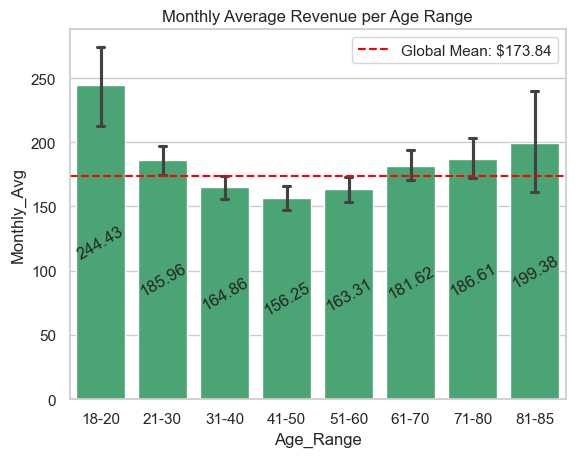

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

order = sorted(df_labeled['Age_Range'].unique())

ax = sns.barplot(data=df_labeled, x='Age_Range', y='Monthly_Avg', capsize=.1,
                 color='mediumseagreen',
                 legend = False,
                 order = order)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type = 'center', rotation = 30)

plt.axhline(df_labeled['Monthly_Avg'].mean(), color ='red', linestyle='--', 
            label = 'Global Mean: $' + str(round(df_labeled['Monthly_Avg'].mean(), 2)))
plt.legend()
plt.title('Monthly Average Revenue per Age Range')

plt.show()

#### Mean of Tenure and $ per Cluster

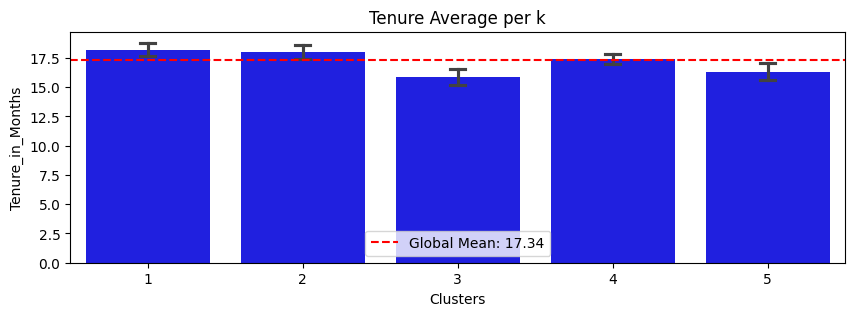

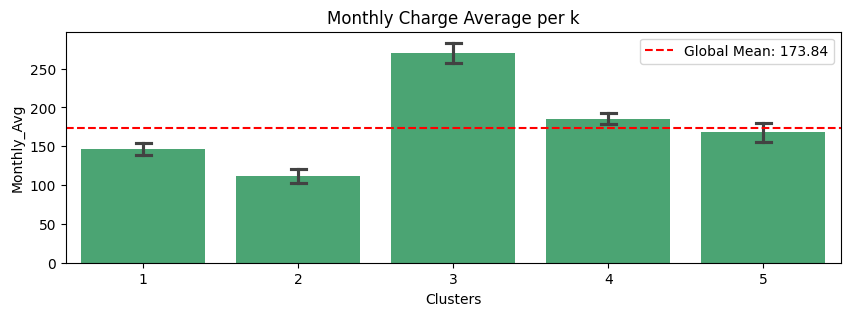

In [9]:
plt.figure(figsize=(10,3))
sns.barplot(data=df_labeled, x='Clusters', y='Tenure_in_Months', capsize=.1, color='blue', legend = False)
plt.title(f'Tenure Average per k')
plt.axhline(df_labeled['Tenure_in_Months'].mean(), color ='red', linestyle='--',
            label = 'Global Mean: ' + str(round(df_labeled['Tenure_in_Months'].mean(), 2)))
plt.legend()

plt.figure(figsize=(10,3))
sns.barplot(data=df_labeled, x='Clusters', y='Monthly_Avg', capsize=.1, color='mediumseagreen', legend = False)
plt.title(f'Monthly Charge Average per k')
plt.axhline(df_labeled['Monthly_Avg'].mean(), color ='red', linestyle='--', 
            label = 'Global Mean: $' + str(round(df_labeled['Monthly_Avg'].mean(), 2)))
plt.legend()
plt.show()

#### Checking cluster medoids + distribution
- Iterate over the list of features chosen from FAMD; means for numerical types, modes for categoricals

In [15]:
#features = contr[contr * 100 > threshold].index.tolist()

features = ['Contract', 'Monthly_Avg', 'Tenure_in_Months', 'Internet_Type']

agg_dict = {}
for col in features:
    if col in df_labeled.select_dtypes(include = [np.number]).columns:
        agg_dict[col] = 'mean'
    else: 
        agg_dict[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else None

#agg_dict |= {'Monthly_Avg': 'count'}

profiles = df_labeled.groupby('Clusters').agg(agg_dict).reset_index()

counts= df_labeled['Clusters'].value_counts(dropna=False)
proportions = round(df_labeled['Clusters'].value_counts(normalize=True) * 100, 2)

summary= pd.concat([counts, proportions], axis = 1)
summary.columns = ['Total Count', 'Data %']

print(summary)
print("-" * 75)
print(profiles)
print("-" * 75)
print(pd.crosstab(df_labeled['Clusters'], df_labeled['Customer_Status'], normalize = 'index') * 100)

          Total Count  Data %
Clusters                     
4                2231   34.76
1                1381   21.52
2                1142   17.79
3                 902   14.05
5                 762   11.87
---------------------------------------------------------------------------
   Clusters        Contract  Monthly_Avg  Tenure_in_Months Internet_Type
0         1  Month-to-Month   146.907552         18.210717           DSL
1         2        Two Year   111.112868         17.984238            No
2         3        One Year   270.645410         15.838137   Fiber Optic
3         4  Month-to-Month   185.526564         17.429404   Fiber Optic
4         5  Month-to-Month   167.888550         16.335958         Cable
---------------------------------------------------------------------------
Customer_Status    Churned     Joined     Stayed
Clusters                                        
1                20.275163   7.530775  72.194062
2                 9.106830  14.623468  76.269702
3   

### 📉 Kaplan-Meier Curve
- In the 80% and median survivability test, _inf_ means _infinity_; 50%+ of the segment has outlasted the max months.

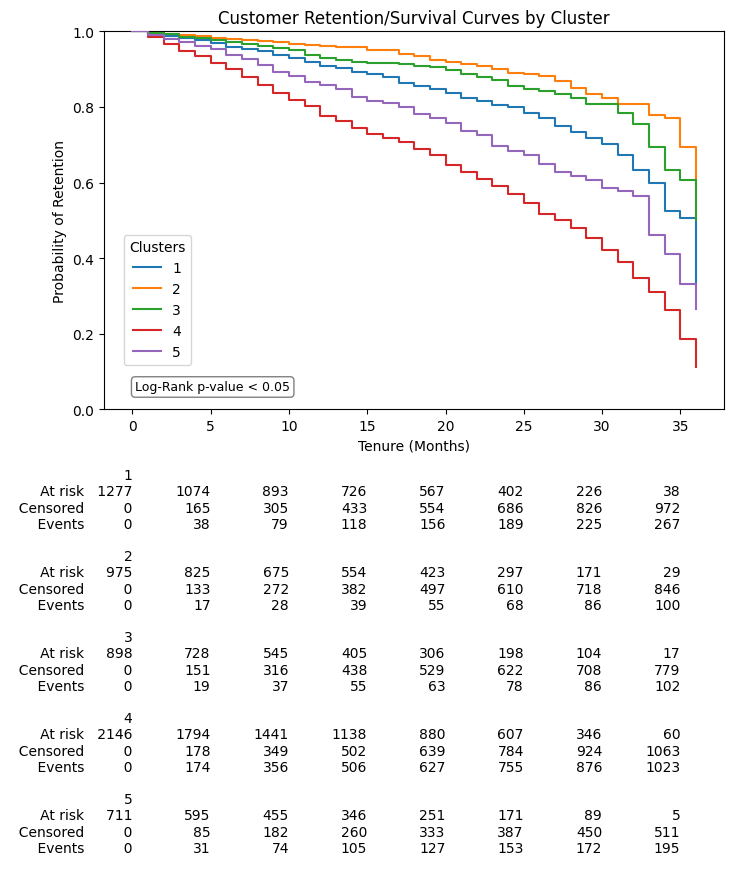

   Cluster  80% Surv hit (months)  Median Surv hit (months)
0        5                   18.0                      33.0
1        4                   12.0                      28.0
2        1                   24.0                      36.0
3        3                   31.0                       inf
4        2                   33.0                       inf


In [17]:
from lifelines import KaplanMeierFitter
from lifelines.utils import qth_survival_times
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)

fitters = []
for cluster in sorted(churn_stayed['Clusters'].unique()):
    mask_cluster = (churn_stayed['Clusters'] == cluster)
    
    kmf = KaplanMeierFitter()
    
    kmf.fit(
        durations = churn_stayed[mask_cluster]['Tenure_in_Months'],
        event_observed = churn_stayed[mask_cluster]['Customer_Status'],
        label = str(cluster))
    kmf.plot_survival_function(ci_show = False, ax=ax, zorder = 3)
    fitters.append(kmf)

# asterisk means "unpack list"
add_at_risk_counts(*fitters, ax=ax)

# The Multivariate_logrank is ran on every cluster of the churn_stayed df
results = multivariate_logrank_test(churn_stayed['Tenure_in_Months'], 
                                    churn_stayed['Clusters'],
                                    churn_stayed['Customer_Status']
                                   )
p_value= results.p_value

p_text = f'Log-Rank p-value {p_value:.4f}' if p_value >= 0.05 else 'Log-Rank p-value < 0.05'

ax.annotate(p_text,
            xy=(0.05,0.05), xycoords='axes fraction',
            fontsize=9, bbox=dict(boxstyle='round',fc='white',ec='gray'), zorder = 20)

ax.set_title('Customer Retention/Survival Curves by Cluster')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Probability of Retention')
ax.set_ylim(0,1)
ax.legend(title='Clusters', loc='lower left', bbox_to_anchor=(0.02, 0.1))
ax.grid(False)
plt.subplots_adjust(bottom=0.25)
plt.savefig(r'C:/Users/Acer/Downloads/KMF.png', bbox_inches = 'tight', dpi = 300)
plt.show()

#print(churn_stayed['Clusters'].value_counts())

milestones = []
for name in churn_stayed['Clusters'].unique():
    group = churn_stayed[churn_stayed['Clusters'] == name]
    kmf.fit(group['Tenure_in_Months'], group['Customer_Status'], label=name)
    
    median = kmf.median_survival_time_
    eighty_percent = qth_survival_times(0.8, kmf.survival_function_)

    milestones.append({
        'Cluster': name,
        '80% Surv hit (months)': eighty_percent,
        'Median Surv hit (months)': median
})

milestone_df = pd.DataFrame.from_dict(milestones)
#print("-" * 60)
print(milestone_df)

### 🔭 Residual Lifetime Value (RLV)
- Past revenue is known; what is the potential for each customer?
- Clusters display distinct RLV accross semesters; valuable strategy tool

In [18]:
import numpy as np
import pandas as pd

def residual_clv(row, max_tenure= df_labeled['Tenure_in_Months'].max()):

    # zip creates pairs of clusters and their medians
    median_dict = dict(zip(milestone_df['Cluster'], milestone_df['Median Surv hit (months)']))
    
    for cluster, median in median_dict.items():
        if median == np.inf or median > max_tenure:
            median_dict[cluster] = max_tenure
            
    cluster = row['Clusters']
    current_tenure = row['Tenure_in_Months']
    monthly_avg = row['Monthly_Avg']
    
    cluster_median = median_dict.get(cluster, max_tenure)

    residual_months = max(0, cluster_median - current_tenure)
    
    # 3 months of presumed residual tenure for survivors
    if residual_months == 0 and current_tenure < max_tenure:
        residual_months = 3 

    return monthly_avg * residual_months

df_labeled['RLV'] = df_labeled.apply(lambda row: residual_clv(row), axis=1)

print(df_labeled[df_labeled['Customer_Status'] != 'Churned'].head(5)
    [['Customer_ID', 'Clusters', 'Tenure_in_Months', 'Monthly_Avg', 'RLV']])
print("-"*70)
print(milestone_df)

  Customer_ID  Clusters  Tenure_in_Months  Monthly_Avg       RLV
0   19877-DEL         5                27        36.10    216.60
1   58353-MAH         5                13        46.94    938.80
5   32750-TEL         5                 2       361.19  11196.89
6   84741-MAH         4                23       374.41   1872.05
7   65618-GUJ         4                24       258.93   1035.72
----------------------------------------------------------------------
   Cluster  80% Surv hit (months)  Median Surv hit (months)
0        5                   18.0                      33.0
1        4                   12.0                      28.0
2        1                   24.0                      36.0
3        3                   31.0                       inf
4        2                   33.0                       inf


#### RLV Binned Heatmap

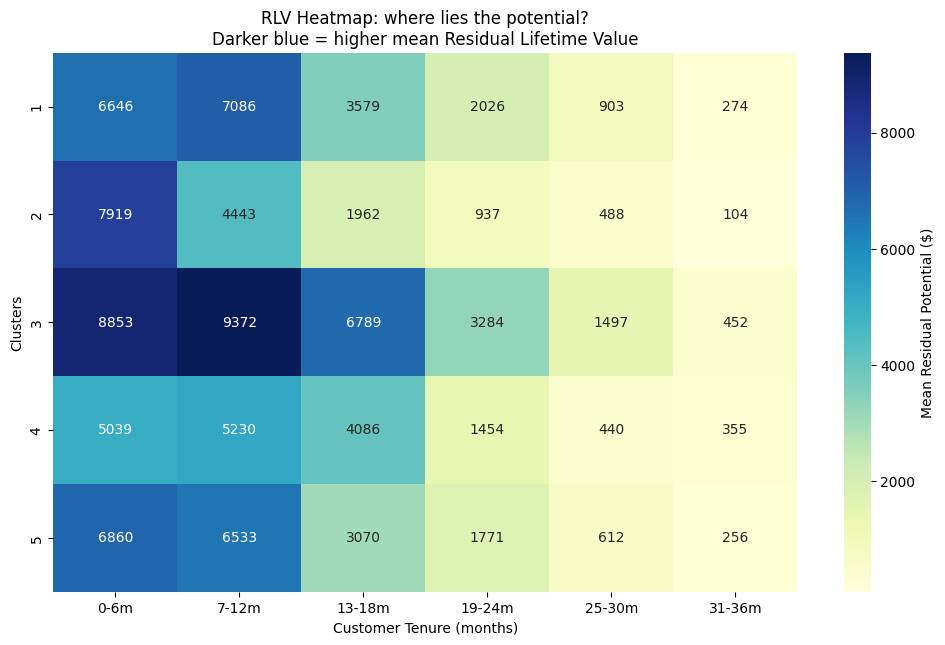

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

bin_size_months = 6
max_tenure = df_labeled['Tenure_in_Months'].max()

# begins at month 0, stops at max_tenure + size (an extra interval) + 1 (to not exclude any multiple of 6), step is the size
bins = list(range(0, int(max_tenure) + bin_size_months + 1, bin_size_months))

# sums 1 to every first number after 0 to avoid repetition. range(len(bins)-1) stops the range at second-to-last
bin_labels = [f'{bins[i] + (1 if i > 0 else 0)}-{bins[i+1]}m' for i in range(len(bins)-1)]

# .cut() for continuous data, bins and labels are custom
df_labeled['Tenure_Range'] = pd.cut(df_labeled['Tenure_in_Months'], bins= bins, 
                            labels= bin_labels)

heatmap_data = df_labeled[df_labeled['Customer_Status'] != 'Churned'].pivot_table(index='Clusters', 
                              columns='Tenure_Range', 
                              values='RLV', 
                              aggfunc='mean', observed = True)
plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={'label': 'Mean Residual Potential ($)'})

plt.title('RLV Heatmap: where lies the potential?\nDarker blue = higher mean Residual Lifetime Value')
plt.xlabel('Customer Tenure (months)')
plt.ylabel('Clusters')
plt.savefig(r'C:/Users/Acer/Downloads/RCLV.png', bbox_inches = 'tight', dpi = 300)
plt.show()

### 🎲 Odds Ratio
- Defining traits are spotted for each segment, allowing for tailored strategies

#### Chi-Square, Laplace smoothing and Lift
- Laplace smoothing (alpha  1.0), p-value and frequency cutoff

In [22]:
from scipy.stats import chi2_contingency

def robust_cluster_profiling(df, cluster_col='Clusters', alpha=1.0, min_freq=0.1):
    
    banished = ['Customer_ID', 'Value_Deal', 'Customer_Status', 'Churn_Reason', 
                'Churn_Category', 'State', 'Internet_Service', 'Tenure_Range', 'RLV']

    categoricals = df_labeled.select_dtypes(exclude=[np.number]).columns
    features = [c for c in categoricals if c not in banished and c != cluster_col ]
    
    results = []
    global_total = len(df)

    for feature in features:

        # chi-square as first filter (p < 0.05)
        ct = pd.crosstab(df[cluster_col], df[feature]) 
        chi2, p, dof, ex = chi2_contingency(ct)

        if p >= 0.05:
            continue

        # index is the category of the column, value is the frequency
        global_counts = df[feature].value_counts()
        
        for cluster in df[cluster_col].unique():
            
            # mask for matching cluster name
            cluster_df = df[df[cluster_col] == cluster]

            # n = (a + b); total length of cluster
            n = len(cluster_df)
            cluster_counts = cluster_df[feature].value_counts()

            for val in global_counts.index:
                
                # x = a; customers WITHIN cluster, WITH category
                x = cluster_counts.get(val, 0)

                # frequency of certain category of certain column div by total row count of that cluster 
                freq = x / n
                
                # 'continue' skips if False
                if freq < min_freq:
                    continue

                # Laplace adds alpha for a smoothed possibility
                # (a + alpha) / (a + b + alpha * 2)
                # smoothed % of WITHIN cluster WITH cat?
                p_cluster_smooth = (x + alpha) / (n + alpha * 2)

                # x_out = everyone OUT of cluster WITH category
                x_out = global_counts[val] - x

                # n_out = ALL of those OUTSIDE of cluster
                n_out = global_total - n

                # smoothed % of OUTSIDE cluster WITH cat?
                p_out_smooth = (x_out + alpha) / (n_out + alpha * 2)

                # log scale of diff between smoothed %
                log_odds = np.log(p_cluster_smooth / (1 - p_cluster_smooth)) - np.log(p_out_smooth / (1 - p_out_smooth))

                # Lift = how many times more the cat appears in that cluster compared to absolute GLOBAL
                lift = freq / (global_counts[val] / global_total)

                results.append({
                    'Cluster': cluster,
                    'Feature': f"{feature}: {val}",
                    'Frequency': round(freq, 3),
                    'Log_Odds_Smooth': round(log_odds, 3),
                    'Lift': round(lift, 3)
                })

    return pd.DataFrame(results).sort_values(['Cluster', 'Log_Odds_Smooth'], ascending=[True, False])

profile_df = robust_cluster_profiling(df_labeled)

print("Customer profile dataframe created. First line:\n")
print(profile_df.iloc[0])

Customer profile dataframe created. First line:

Cluster                             1
Feature            Internet_Type: DSL
Frequency                         1.0
Log_Odds_Smooth                10.928
Lift                            4.273
Name: 29, dtype: object


#### Inclination Summary

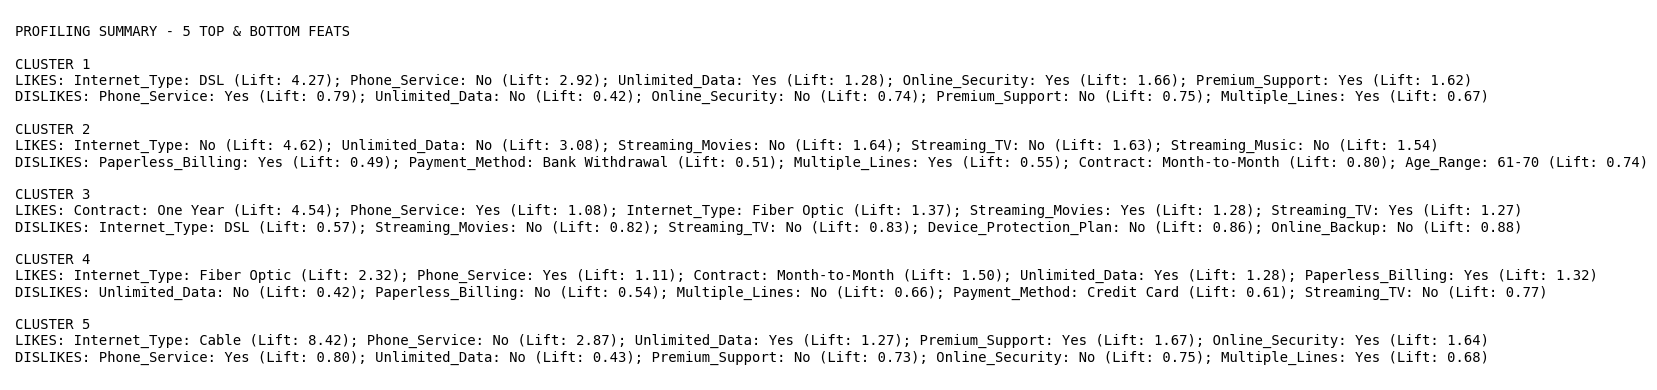

In [23]:
# only significant impacts
log_cutoff = 0.5

# only categories with x1.5+ freq
lift_cutoff = 1.5

fig, ax = plt.subplots(figsize=(12, 4)) 
ax.axis('off')

chosen_num = 5
text_output = f"PROFILING SUMMARY - {chosen_num} TOP & BOTTOM FEATS\n"

#print(f"PROFILING SUMMARY - {chosen_num} TOP & BOTTOM FEATS")

for cluster in sorted(profile_df['Cluster'].unique()):
    cluster_mask = profile_df[profile_df['Cluster'] == cluster]

    likes_df = cluster_mask[cluster_mask['Log_Odds_Smooth'] > 0]
    dislikes_df = cluster_mask[cluster_mask['Log_Odds_Smooth'] < 0]

    top_rows = likes_df.nlargest(chosen_num, 'Log_Odds_Smooth')
    top_feats = [f"{row['Feature']} (Lift: {row['Lift']:.2f})" for _, row in top_rows.iterrows()]
    
    bottom_rows = dislikes_df.nsmallest(chosen_num, 'Log_Odds_Smooth')
    bottom_feats = [f"{row['Feature']} (Lift: {row['Lift']:.2f})" for _, row in bottom_rows.iterrows()]

    text_output += f"\nCLUSTER {cluster}\n" 
    text_output += f"LIKES: {'; '.join(top_feats)}\n"
    text_output += f"DISLIKES: {'; '.join(bottom_feats)}\n"

    #print(f"\nCLUSTER {cluster}") 
    #print(f"💚 {'; '.join(top_feats)}")
    #print(f"💔 {'; '.join(bottom_feats)}")

plt.text(0.01, 0.95, text_output, 
         family='monospace', 
         fontsize=10, 
         verticalalignment='top', 
         transform=ax.transAxes)

plt.tight_layout()
plt.savefig(r'C:/Users/Acer/Downloads/Profiling_Summary.png', dpi=300, bbox_inches='tight', facecolor= 'white')

### 🏷 Cluster Labeling

In [24]:
cluster_names = {
    1: 'Traditionalist',
    2: 'Stable Bundler',
    3: 'Loyalist',
    4: 'Savvy Nomad',
    5: 'Niche Surfer'}

df_labeled['Clusters'] = df_labeled['Clusters'].map(cluster_names)

In [30]:
print('Cluster names mapped:\n', df_labeled.groupby('Clusters')['Customer_ID'].count())

Cluster names mapped:
 Clusters
Loyalist           902
Niche Surfer       762
Savvy Nomad       2231
Stable Bundler    1142
Traditionalist    1381
Name: Customer_ID, dtype: int64


#### Distribution Plots

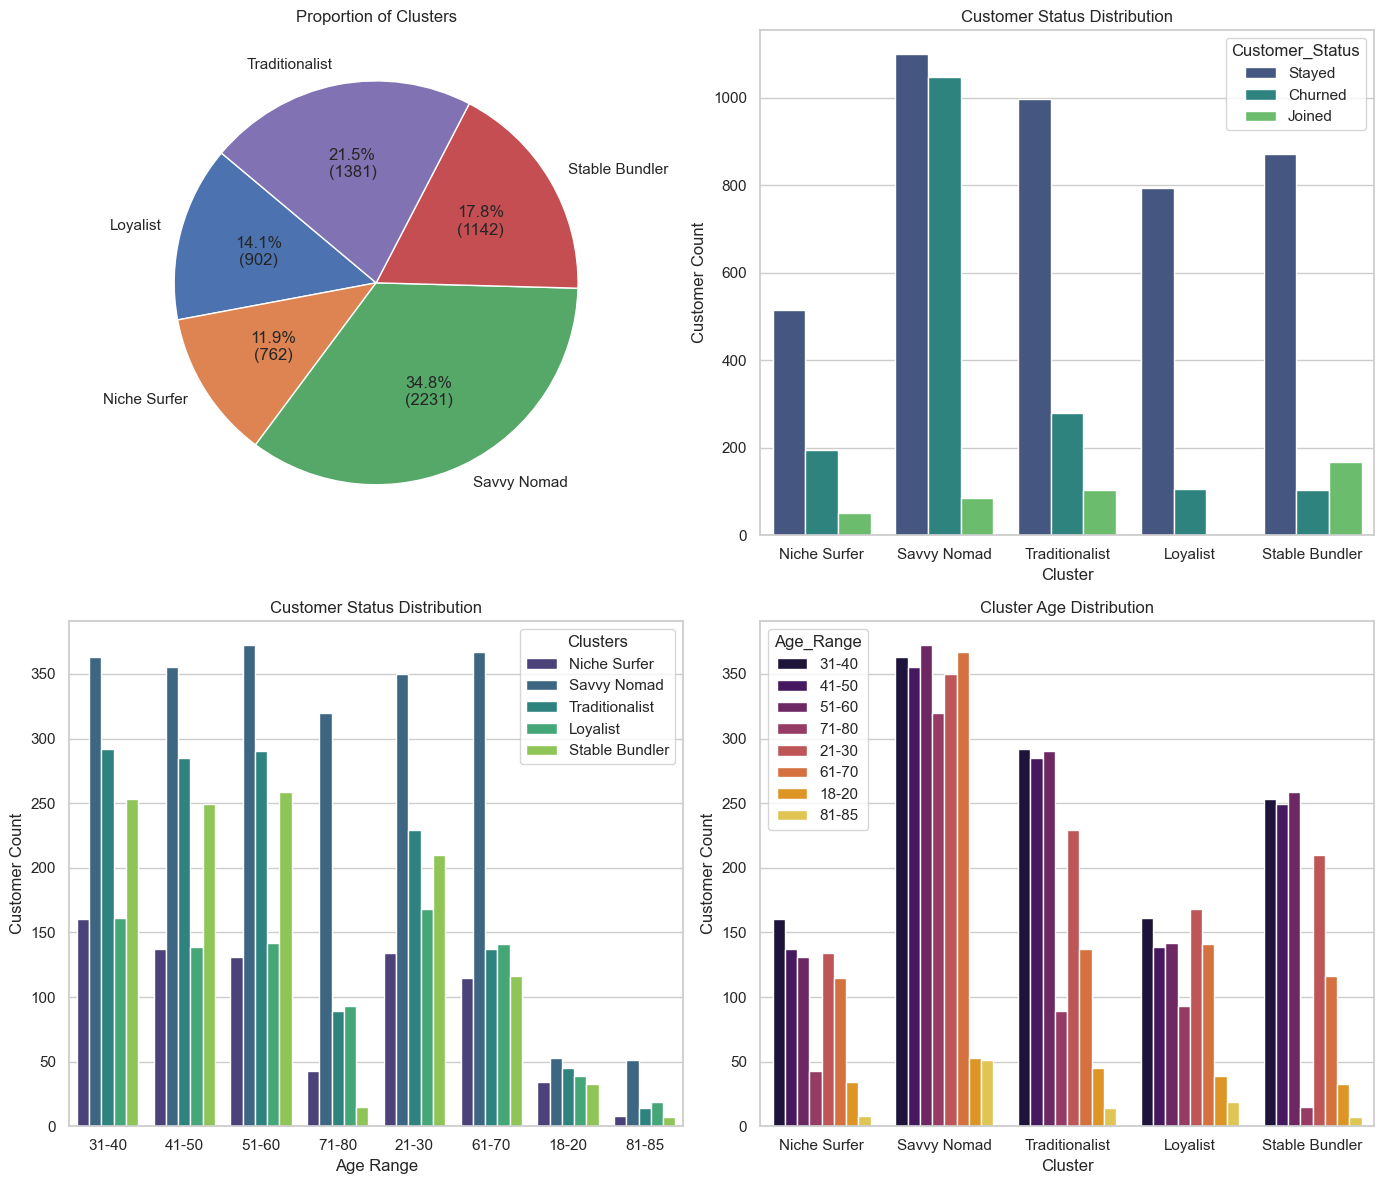

In [32]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14,12))

plt.subplot(2,2,1)
cluster_counts = df_labeled['Clusters'].value_counts().sort_index()
total = sum(cluster_counts)

def make_autopct(values):
    def my_autopct(pct):
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:d})'
    return my_autopct

plt.pie(cluster_counts,
        labels=[i for i in cluster_counts.index],
        autopct= make_autopct(cluster_counts),
        startangle=140
        #, colors=sns.color_palette("magma", len(cluster_counts))
)
plt.title('Proportion of Clusters')

plt.subplot(2,2,2)
sns.countplot(data= df_labeled, x= df_labeled['Clusters'], hue= df_labeled['Customer_Status'], palette='viridis')
plt.title('Customer Status Distribution')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()

plt.subplot(2,2,3)
sns.countplot(data= df_labeled, x=df_labeled['Age_Range'], hue= df_labeled['Clusters'], palette='viridis')
plt.title('Age Range Distribution')
plt.xlabel('Age Range')
plt.ylabel('Customer Count')
plt.tight_layout()

plt.subplot(2,2,4)
sns.countplot(data= df_labeled, x=df_labeled['Clusters'], hue= df_labeled['Age_Range'], palette='inferno')
plt.title('Cluster Age Distribution')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()

plt.savefig(r'C:/Users/Acer/Downloads/age_distributions', bbox_inches = 'tight', dpi = 300)

### 🗺 State Drivers
- Encode WoE on categoricals with WOEEncoder, and insert top correlations
- Synth data hasn't accounted for relevant regional upsides; most states have near 0 retention drivers.
- Only features related to the State - not the Clusters - matter

In [37]:
from category_encoders import WOEEncoder

pd.set_option('display.max_colwidth', None)

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})
churn_stayed['State_WoE'] = churn_stayed['State']

cols_to_encode = churn_stayed.drop(['Customer_ID', 'Value_Deal', 'Total_Revenue', 'State',
                                    'Churn_Reason', 'Churn_Category', 'Internet_Service',
                                    'Clusters', 'Age_Range', 'Contract'
                                   ],
                                   axis=1).select_dtypes(exclude = [np.number]).columns.tolist()

encoder = WOEEncoder(cols=cols_to_encode)

# every cat column is numeric in df_encoded!
df_encoded = encoder.fit_transform(churn_stayed, churn_stayed['Customer_Status'])

churn_stayed = churn_stayed.drop('State_WoE', axis = 1)

def get_state_drivers(df, target_col, feature_cols):
    state_report = []

    for state in df['State'].unique():
        
        # mask for every matching State
        subset = df[df['State'] == state]
        
        # churn(1)/stayed(0)
        churn_rate = subset[target_col].mean()

        state_revenue = subset['Total_Revenue'].sum()

        state_woe = round(subset['State_WoE'].iloc[0], 3)

        # how much does each column correlate to churning/staying?
        correlations = subset[feature_cols + [target_col]].corr()[target_col].drop(target_col)

        pos_corr = correlations[correlations > 0].sort_values(ascending=False).head(3)
        
        # .items() returns key-value pair; idx for col names and val for corr vals
        churn_drivers = [f"{idx} ({val:.2f})" for idx, val in pos_corr.items()]

        neg_corr = correlations[correlations < 0].sort_values(ascending=True).head(3)
        retention_drivers = [f"{idx} ({val:.2f})" for idx, val in neg_corr.items()]

        state_report.append({
            'State': state,
            'State_WoE': state_woe,
            #'State_Revenue': state_revenue,
            'Churn_Rate': f"{round(churn_rate * 100, 2)}%",
            'Top_Churn_Drivers': "\n".join(churn_drivers),
            'Top_Retention_Drivers': "\n".join(retention_drivers)
        })
    
    return pd.DataFrame(state_report)

# features to assess correlation with Customer_Status; it'll range from -1 to 1, and define drivers.
features = churn_stayed.drop(['Customer_ID', 'Value_Deal', 'Total_Revenue', 'State',
                              'Churn_Reason', 'Churn_Category', 'Internet_Service', 
                              'Clusters', 'Age_Range', 'Contract', 'RLV'
                             ],
                             axis=1).select_dtypes(exclude = [np.number]).columns.tolist()

state_drivers = get_state_drivers(df_encoded, 'Customer_Status', features)

state_drivers = state_drivers.sort_values(by='Churn_Rate', ascending=False)

print("State Drivers dataframe created!\n")
print('Top 5 highest Churn Rates:\n', state_drivers[['State', 'State_WoE', 'Churn_Rate']].head())
print("=" * 40)
print('Top 5 lowest Churn Rates:\n', state_drivers[['State', 'State_WoE', 'Churn_Rate']].tail())

State Drivers dataframe created!

Top 5 highest Churn Rates:
               State  State_WoE Churn_Rate
16  Jammu & Kashmir      1.243     58.47%
17            Assam      0.548     41.09%
14        Jharkhand      0.387     37.14%
12     Chhattisgarh      0.210     32.73%
0             Delhi      0.160     31.93%
Top 5 lowest Churn Rates:
              State  State_WoE Churn_Rate
3        Karnataka     -0.223     24.37%
13          Punjab     -0.229     24.22%
11  Madhya Pradesh     -0.235     24.07%
6          Gujarat     -0.269     23.49%
18     Uttarakhand     -0.239     23.33%


#### State Drivers Table Plot 

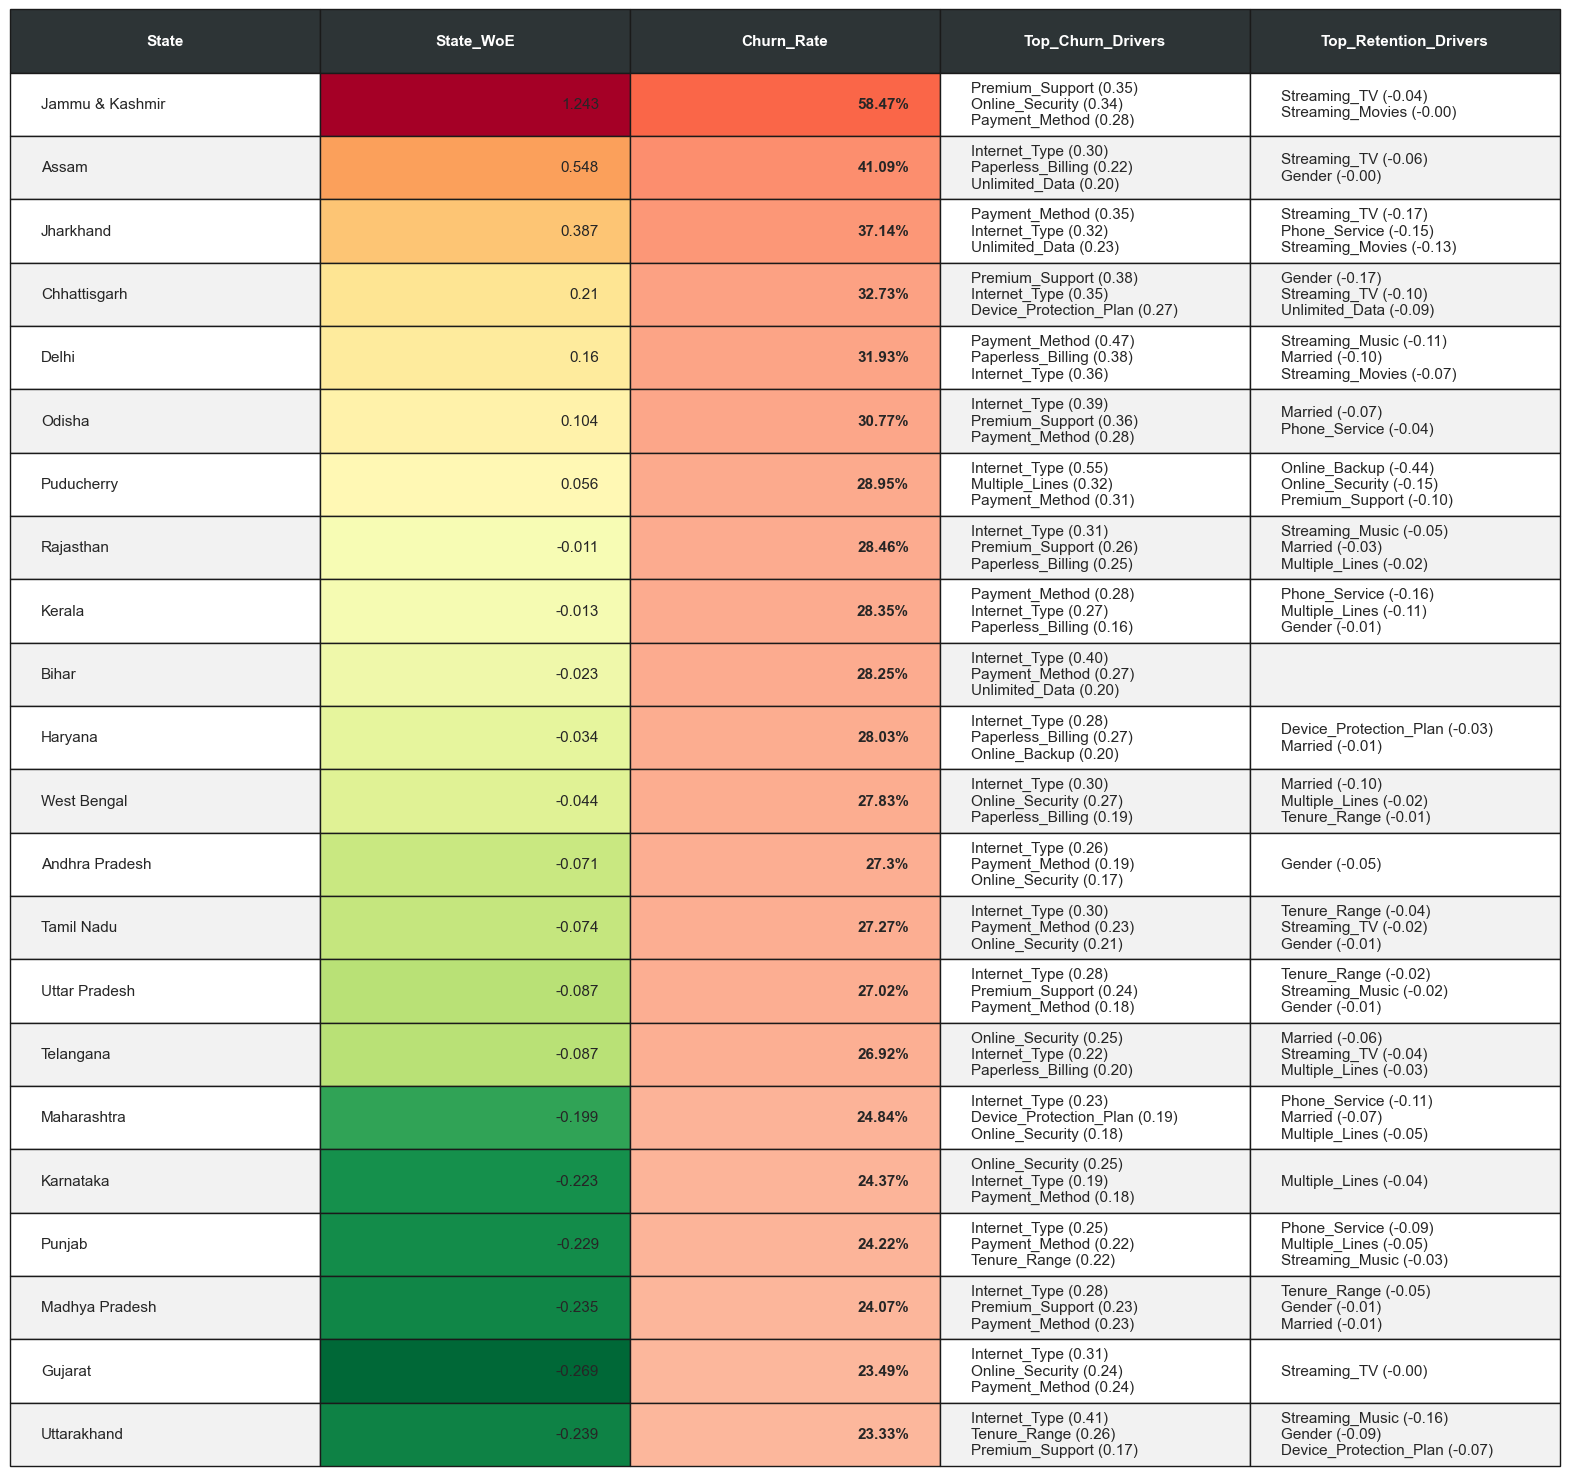

In [38]:
import matplotlib.colors as mcolors

def render_compact_table(df, filename='C:/Users/Acer/Downloads/state_drivers_clean.png'):
    fig, ax = plt.subplots(figsize=(20, 18)) 
    ax.axis('off')

    table = ax.table(
        cellText=df.values, 
        colLabels=df.columns, 
        cellLoc='left',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 3.8) 

    for i, key in enumerate(table._cells):
        cell = table._cells[key]
        if key[0] == 0: #header
            cell.set_facecolor('#40466e')
            cell.set_text_props(color='w', weight='bold')
        elif key[0] % 2 == 0:
            cell.set_facecolor('#f2f2f2')
    
    def parse_churn(val):
        try: return float(val.replace('%', '')) / 100
        except: return 0

    woe_cmap = plt.cm.RdYlGn_r
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=df['State_WoE'].min(), vmax=df['State_WoE'].max())
    
    churn_cmap = plt.cm.Reds

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2d3436')
            cell.set_text_props(color='w', weight='bold', ha = 'center')
            continue

        col_name = df.columns[col]
        cell_text = cell.get_text().get_text()

        if col_name in ['State_WoE', 'Churn_Rate']:
            cell.get_text().set_ha('right')
        
        if col_name == 'State_WoE':
            try:
                val = float(cell_text)
                cell.set_facecolor(woe_cmap(norm(val)))
            except ValueError:
                pass
        elif col_name == 'Churn_Rate':
            def parse_churn(val):
                try: return float(val.replace('%', '')) / 100
                except: return 0
                    
            rate = parse_churn(cell_text)
            color_idx = 0.1 + (rate * 0.7) 
            cell.set_facecolor(churn_cmap(color_idx))
            cell.set_text_props(weight='bold')
        
    plt.savefig(filename, dpi=200, bbox_inches='tight', pad_inches = 0.05)
    plt.show()

render_compact_table(state_drivers)

### 📈 COX PH 

#### Concordance Index and Assumption check
- 0.55 onwards is acceptable, and filter by p 

In [51]:
import pandas as pd
import numpy as np
from category_encoders import WOEEncoder
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from contextlib import redirect_stdout
import io

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

duration_col = 'Tenure_in_Months'
event_col = 'Customer_Status'

churn_stayed = churn_stayed.dropna(subset=[duration_col, event_col])

exclude_cols = ['Customer_ID', 'Value_Deal', 'Total_Revenue', 'Churn_Reason', 
                'Churn_Category', 'Internet_Service', 'Tenure_Range',
                'Age_Range', 'RLV', duration_col, event_col]

cols_to_encode = [c for c in churn_stayed.select_dtypes(exclude= [np.number]).columns if c not in exclude_cols]

encoder = WOEEncoder(cols=cols_to_encode)
df_woe = encoder.fit_transform(churn_stayed[cols_to_encode], churn_stayed[event_col])
print(f"WOEEncoder applied to {len(cols_to_encode)} columns.\n")
      
df_analysis = pd.concat([df_woe, churn_stayed[[duration_col, event_col]]], axis=1)

cox_results = []
relevant_cols = []

for col in cols_to_encode:
    try:
        temp_df = df_analysis[[col, duration_col, event_col]].dropna()
        
        cph = CoxPHFitter()
        cph.fit(temp_df, duration_col=duration_col, event_col=event_col)
        
        c_index = concordance_index(temp_df[duration_col], -temp_df[col], temp_df[event_col])

        # shush
        with redirect_stdout(io.StringIO()):
            assumptions = cph.check_assumptions(temp_df, p_value_threshold=0.05, show_plots=False, advice = False)
        
        is_proportional = True if not assumptions else False
        
        cox_results.append({
            'Column': col,
            'C-Index': round(c_index, 4),
            'P-value (HR)': round(cph.summary.loc[col, 'p'], 4),
            'Valid_Prop': is_proportional,
            'Hazard_Ratio': round(cph.hazard_ratios_[col], 4)
        })

        # only moderate/strong c-index, and valid p
        if 0.55 <= c_index < 0.95 and cph.summary.loc[col, 'p'] < 0.05:
            relevant_cols.append(col)

    except Exception as e:
        print(f"Error in {col}: {e}")

results_df = pd.DataFrame(cox_results).sort_values(by='C-Index', ascending=False)

print(results_df)

print(f"\nColumn suggestions:\n{relevant_cols}")

WOEEncoder applied to 18 columns.



                    Column  C-Index  P-value (HR)  Valid_Prop  Hazard_Ratio
14                Contract   0.7117        0.0000        True        2.1435
17                Clusters   0.6560        0.0000        True        2.0085
5            Internet_Type   0.6310        0.0000        True        2.0864
16          Payment_Method   0.5903        0.0000        True        2.1010
15       Paperless_Billing   0.5720        0.0000        True        2.1265
9          Premium_Support   0.5701        0.0000        True        2.0887
6          Online_Security   0.5690        0.0000        True        2.1568
13          Unlimited_Data   0.5634        0.0000        True        2.2318
2                    State   0.5573        0.0000        True        1.9773
7            Online_Backup   0.5384        0.0000        True        2.0393
8   Device_Protection_Plan   0.5344        0.0000        True        1.9285
12         Streaming_Music   0.5196        0.0094        True        2.9291
0           

#### Base Cluster WoE

In [40]:
cluster_mapping = pd.DataFrame({
    'Cluster_OG': churn_stayed['Clusters'],
    'WoE_Value': df_analysis['Clusters']
}).drop_duplicates().sort_values(by='WoE_Value', ascending = False)

print(cluster_mapping)

        Cluster_OG  WoE_Value
2      Savvy Nomad   0.854394
0     Niche Surfer  -0.060082
8   Traditionalist  -0.364578
16        Loyalist  -1.110823
24  Stable Bundler  -1.214008


#### CPH Plot

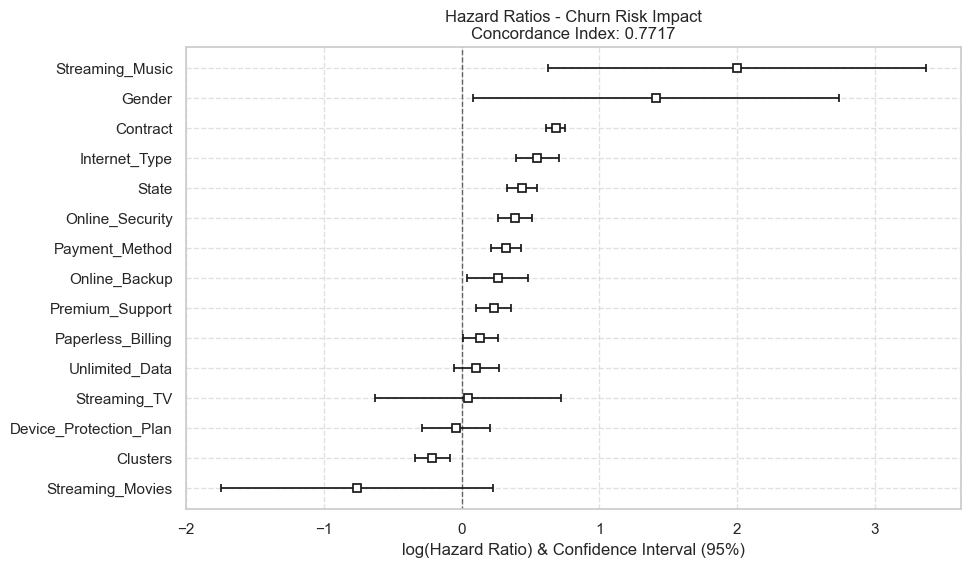


Top 5 Greatest HR:
                 exp(coef)             p
covariate                               
Streaming_Music   7.371908  4.307208e-03
Gender            4.093173  3.775056e-02
Contract          1.978343  1.732728e-78
Internet_Type     1.730406  5.731275e-12
State             1.553929  2.386831e-15


In [41]:
selected_features = results_df[results_df['P-value (HR)'] < 0.05]['Column'].tolist()

cols_final = selected_features + [duration_col, event_col]
df_final = df_analysis[cols_final].dropna()

cph_final = CoxPHFitter()
cph_final.fit(df_final, duration_col=duration_col, event_col=event_col)

#cph_final.print_summary()
plt.figure(figsize=(10, 6))
cph_final.plot()
plt.title(f'Hazard Ratios - Churn Risk Impact\nConcordance Index: {cph_final.concordance_index_:.4f}')
plt.xlabel('log(Hazard Ratio) & Confidence Interval (95%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(r'C:/Users/Acer/Downloads/COX.png', bbox_inches = 'tight', dpi = 300)
plt.show()

chosen_top = 5
summary = cph_final.summary
print(f"\nTop {chosen_top} Greatest HR:")
print(summary[['exp(coef)', 'p']].sort_values(by='exp(coef)', ascending=False).head(chosen_top))

### 🎯 Campaign Simulation

#### Actionable Minimizers
- Search for retaining values that can be part of interventions/incetives
- Must follow logic; marketing can't "sell" a gender, or regional change, or marital status (I think). 

In [46]:
duration_col = 'Tenure_in_Months'
event_col = 'Customer_Status'

churn_stayed = churn_stayed.dropna(subset=[duration_col, event_col])

exclude_cols = ['Customer_ID', 'Value_Deal', 'Total_Revenue', 'Churn_Reason', 
                'Churn_Category', 'Internet_Service', 'Tenure_Range',
                'Age_Range', 'RLV', duration_col, event_col]

cols_to_encode = [c for c in churn_stayed.select_dtypes(exclude= [np.number]).columns if c not in exclude_cols]

results = []
for col in cols_to_encode:
    min_woe = df_woe[col].min()
    match_idx = df_woe[df_woe[col] == min_woe].index[0]
    
    original_val = churn_stayed.loc[match_idx, col]
    col_val_string = f"{col}: {original_val}"
    
    results.append({
        'Feature': col_val_string,
        'WoE': min_woe})

df_min_woe = pd.DataFrame(results).sort_values(by='WoE', ascending = True)

print("Greatest retention influencing features, by WoE:\n", df_min_woe)

cols_to_encode = [c for c in cols_to_encode if c not in ['Gender', 'State', 'Married', 'Clusters']]

for col in cols_to_encode:
    print(f"\nWoE for {col}")
    table = pd.DataFrame({
    col: churn_stayed[col],
    'WoE': df_analysis[col].round(2)
    }).drop_duplicates().sort_values(by='WoE', ascending = True)
    print(table)

Greatest retention influencing features, by WoE:
                         Feature       WoE
14           Contract: Two Year -2.636325
5             Internet_Type: No -1.413308
17     Clusters: Stable Bundler -1.214008
6          Online_Security: Yes -0.833761
9          Premium_Support: Yes -0.769412
16  Payment_Method: Credit Card -0.741671
15        Paperless_Billing: No -0.585768
13           Unlimited_Data: No -0.583109
7            Online_Backup: Yes -0.330432
8   Device_Protection_Plan: Yes -0.302543
2                State: Gujarat -0.268629
11         Streaming_Movies: No -0.072846
10             Streaming_TV: No -0.068820
3             Phone_Service: No -0.056436
0                  Gender: Male -0.046985
12          Streaming_Music: No -0.044676
1                  Married: Yes -0.023769
4            Multiple_Lines: No -0.018510

WoE for Phone_Service
   Phone_Service   WoE
10            No -0.06
0            Yes  0.01

WoE for Multiple_Lines
  Multiple_Lines   WoE
0            

#### Counterfactual Survivability
- Achieving One Year Contract is an important step; bundles should look for upselling + 1 year
- Bundling ROI would only be assessed with implementation costs and CAC.
- IMPORTANT: with CPH data and WoE, the assumption is of constant efficay through months, without decay.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# df for bundling must contain come from CPH and have WoE cols
bundles = {
    "Base": {},
    "One_Year_Contract": {"Contract": -1.16}, # 1 year WoE
    "Two_Year_Contract": {"Contract": df_analysis['Contract'].min()},
    "Golden_Bundle": {
        "Contract": -1.16, # 1 year WoE
        "Device_Protection_Plan": df_analysis['Device_Protection_Plan'].min(),
        "Online_Backup": df_analysis['Online_Backup'].min(),
        "Premium_Support": df_analysis['Premium_Support'].min(),
        "Online_Security": df_analysis['Online_Security'].min()
    },
    "Platinum_Bundle": {
        "Contract": df_analysis['Contract'].min(), # 2 year WoE
        "Device_Protection_Plan": df_analysis['Device_Protection_Plan'].min(),
        "Online_Backup": df_analysis['Online_Backup'].min(),
        "Premium_Support": df_analysis['Premium_Support'].min(),
        "Online_Security": df_analysis['Online_Security'].min()
    }
}

clusters_unique = sorted(churn_stayed['Clusters'].unique())
n_clusters = len(clusters_unique)
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 5 * n_clusters), sharex=True)

#colors = {'Base': '#34495e', 
#          'Safe_Contract': '#e67e22', 
#          'Spoil_Bundle': '#27ae60'}

results_summary = []

for i, cluster_id in enumerate(clusters_unique):
    ax = axes[i]

    # .T for transpose
    cluster_median = df_analysis[churn_stayed['Clusters'] == cluster_id].median().to_frame().T
    
    ax = axes[i] if len(clusters_unique) > 1 else axes
    
    for name, changes in bundles.items():
        scenario = cluster_median.copy()
        for col, val in changes.items():
            scenario[col] = val

        surv = cph_final.predict_survival_function(scenario)
        ax.plot(surv.index, surv.values, label=name, lw=2.5) #,color=colors.get(name) )

        months = 36
        idx = surv.index.get_indexer([months], method='nearest')[0]
        prob_m = surv.iloc[idx].values[0]
        results_summary.append({'Cluster': cluster_id, 
                                'Bundle': name, 
                                'Retention_m': prob_m})
        
    ax.set_title(f'Intervention Impact - {cluster_id}', fontsize=13)
    ax.set_ylabel('Retention Prob.')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower left')

plt.xlabel(f'Tenure over {months} months')
plt.tight_layout()
plt.savefig(r'C:/Users/Acer/Downloads/Counterfactual.png')
plt.show()

df_performance = pd.DataFrame(results_summary)
print(df_performance.pivot(index='Cluster', columns='Bundle', values='Retention_m'))

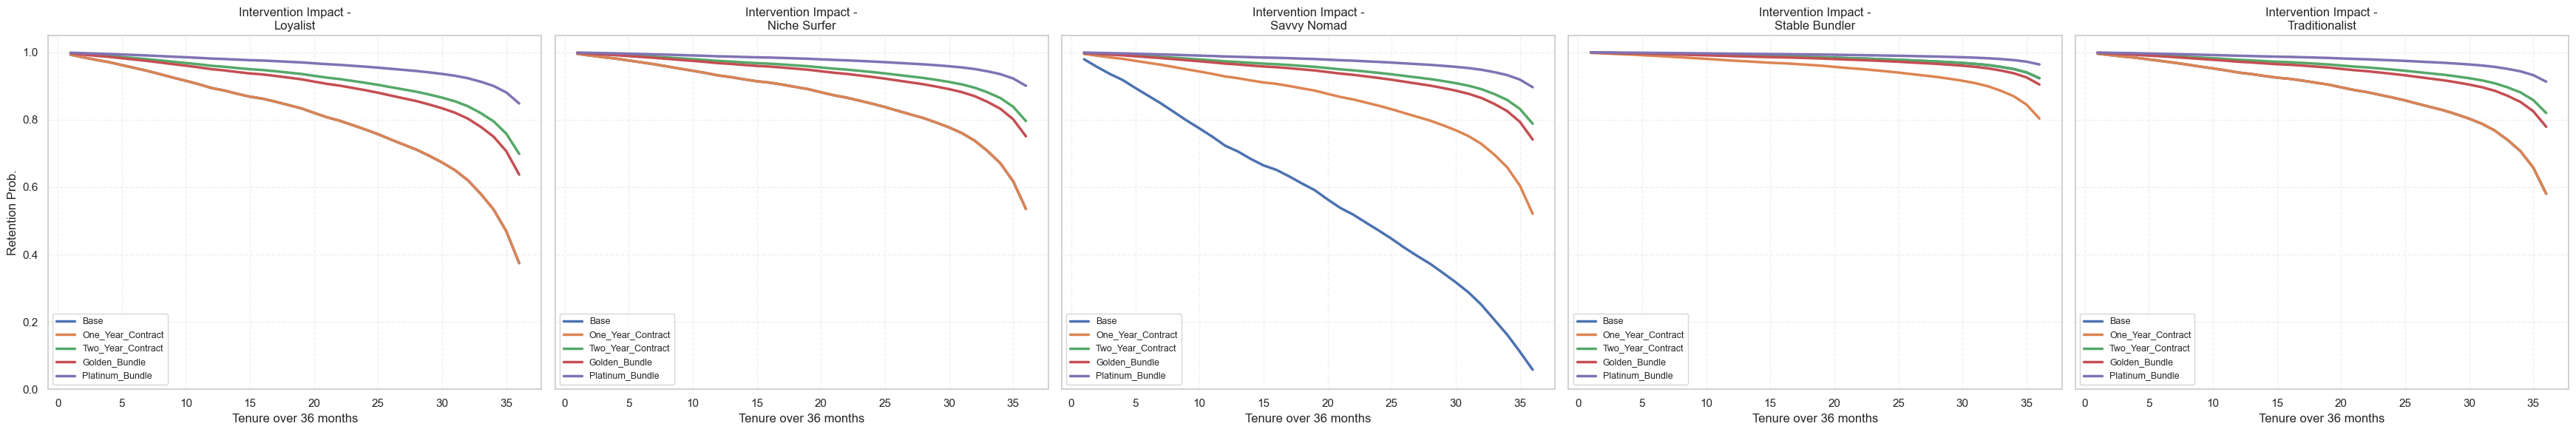

Bundle              Base  Golden_Bundle  One_Year_Contract  Platinum_Bundle  \
Cluster                                                                       
Loyalist        0.374317       0.637065           0.374581         0.848169   
Niche Surfer    0.535213       0.750648           0.535453         0.900546   
Savvy Nomad     0.058214       0.741181           0.520856         0.896381   
Stable Bundler  0.923146       0.904351           0.803360         0.963947   
Traditionalist  0.580343       0.779055           0.580569         0.912847   

Bundle          Two_Year_Contract  
Cluster                            
Loyalist                 0.698630  
Niche Surfer             0.796016  
Savvy Nomad              0.788021  
Stable Bundler           0.923146  
Traditionalist           0.819885  


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# df for bundling must contain come from CPH and have WoE cols
bundles = {
    "Base": {},
    "One_Year_Contract": {"Contract": -1.16}, # 1 year WoE
    "Two_Year_Contract": {"Contract": df_analysis['Contract'].min()},
    "Golden_Bundle": {
        "Contract": -1.16, # 1 year WoE
        "Device_Protection_Plan": df_analysis['Device_Protection_Plan'].min(),
        "Online_Backup": df_analysis['Online_Backup'].min(),
        "Premium_Support": df_analysis['Premium_Support'].min(),
        "Online_Security": df_analysis['Online_Security'].min()
    },
    "Platinum_Bundle": {
        "Contract": df_analysis['Contract'].min(), # 2 year WoE
        "Device_Protection_Plan": df_analysis['Device_Protection_Plan'].min(),
        "Online_Backup": df_analysis['Online_Backup'].min(),
        "Premium_Support": df_analysis['Premium_Support'].min(),
        "Online_Security": df_analysis['Online_Security'].min()
    }
}

clusters_unique = sorted(churn_stayed['Clusters'].unique())
n_clusters = len(clusters_unique)

# --- CHANGED: 1 row, n_clusters columns. Inverted figsize to be wide (e.g., 5 width per plot, 5 height) ---
fig, axes = plt.subplots(1, n_clusters, figsize=(7 * n_clusters, 6), sharey=True)

results_summary = []

for i, cluster_id in enumerate(clusters_unique):
    # Ensure axes indexing works perfectly if there's only 1 cluster, though usually there are more
    ax = axes[i] if n_clusters > 1 else axes

    cluster_median = df_analysis[churn_stayed['Clusters'] == cluster_id].median().to_frame().T
    
    for name, changes in bundles.items():
        scenario = cluster_median.copy()
        for col, val in changes.items():
            scenario[col] = val

        surv = cph_final.predict_survival_function(scenario)
        ax.plot(surv.index, surv.values, label=name, lw=2.5)

        months = 36
        idx = surv.index.get_indexer([months], method='nearest')[0]
        prob_m = surv.iloc[idx].values[0]
        results_summary.append({'Cluster': cluster_id, 
                                'Bundle': name, 
                                'Retention_m': prob_m})
        
    ax.set_title(f'Intervention Impact -\n{cluster_id}', fontsize=12) # Added a newline so long names don't overlap
    ax.set_xlabel(f'Tenure over {months} months') # --- CHANGED: Moved X-label to individual axes since they are horizontal
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower left', fontsize=9)

# --- CHANGED: Set Y-label only on the first leftmost plot to avoid clutter since sharey=True ---
if n_clusters > 1:
    axes[0].set_ylabel('Retention Prob.')
else:
    axes.set_ylabel('Retention Prob.')

plt.tight_layout()
plt.savefig(r'C:/Users/Acer/Downloads/Counterfactual.png')
plt.show()

df_performance = pd.DataFrame(results_summary)
print(df_performance.pivot(index='Cluster', columns='Bundle', values='Retention_m'))

## 🔮 Prediction and Profiling

### 🏎 Binary Classification w/ XGBoost
- Using Monthly_Avg worsens model; use original monetary columns
- Best: df_labeled without Monthly_Avg

#### Optuna + StratifiedKFold for tuned model

✓ Finished train/test split (Holdout created);
✓ Optuna study created;
✓ Categorical columns encoded with WoE;
✓ Trials for best convergence: 325
✓ Tuned model trained;

⌛ Execution time of script: 30.79 secs.

Best params: {'learning_rate': 0.010946614597606862, 'max_depth': 5, 'subsample': 0.5797762761675908, 'colsample_bytree': 0.9424887825625825}

Optimal cutoff/threshold: 0.3873
AUC-PR on Test: 0.8212

Confusion Matrix (Test Data):
[[756  99]
 [ 91 256]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       855
           1       0.72      0.74      0.73       347

    accuracy                           0.84      1202
   macro avg       0.81      0.81      0.81      1202
weighted avg       0.84      0.84      0.84      1202



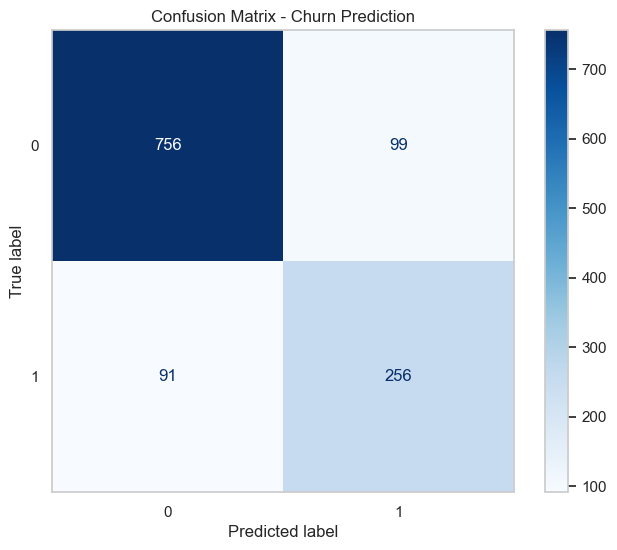

In [62]:
import time
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
from optuna.integration import XGBoostPruningCallback
from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)
from category_encoders import WOEEncoder

start = time.time()

churn_stayed = df_labeled.copy()[df_labeled['Customer_Status'] != 'Joined']
churn_stayed['Customer_Status'] = churn_stayed['Customer_Status'].map({'Stayed': 0, 'Churned': 1})
churn_stayed['Clusters'] = churn_stayed['Clusters'].astype(str)

target = 'Customer_Status'

banished = ['Customer_ID', 'Value_Deal', 'Churn_Reason',
            'Churn_Category', 'Internet_Service', 'Monthly_Avg',
            'Age_Range']

monetary = ['Monthly_Charge', 'Total_Charges', 'Total_Long_Distance_Charges', 
            'Total_Extra_Data_Charges', 'Total_Refunds']

# Not excluding monetary columns 
to_drop = [target] + banished

X = churn_stayed.drop(columns= to_drop)
y = churn_stayed[target]

cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

if target in cat_cols:
		cat_cols.remove(target)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("✓ Finished train/test split (Holdout created);")

def objective(trial):
    params = {
        "verbosity": 0,
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }
		
    # 5 folds being done in cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    auc_scores = []

    # For UserWarnings to stop (callback/interruption at very first fold):
    scores = []
    best_rounds = []
    
    for i, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):

        if i == 0:
            pruning_callback = XGBoostPruningCallback(trial, "val-aucpr")
            callbacks = [pruning_callback]
        else:
            callbacks = []
        
        X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
        
        encoder = WOEEncoder(cols=cat_cols)
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_val_enc = encoder.transform(X_val)
        
        dtrain = xgb.DMatrix(X_train_enc, label = y_train)
        dval = xgb.DMatrix(X_val_enc, label = y_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds= 50,
            callbacks = callbacks,
            verbose_eval=False
        )

        scores.append(model.best_score)
        best_rounds.append(model.best_iteration)
        
        auc_scores.append(model.best_score)
    
    trial.set_user_attr("best_round", int(np.mean(best_rounds)))
    
    return np.mean(auc_scores)

# Log to show only actual warnings and errors, not trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction = "maximize", pruner = optuna.pruners.MedianPruner())		
study.optimize(objective, n_trials=50)
print("✓ Optuna study created;")

final_encoder = WOEEncoder(cols= cat_cols)
print("✓ Categorical columns encoded with WoE;")

X_train_final_enc = final_encoder.fit_transform(X_train_full, y_train_full)
X_test_enc = final_encoder.transform(X_test)

dtrain_final = xgb.DMatrix(X_train_final_enc, label=y_train_full)
dtest = xgb.DMatrix(X_test_enc, label=y_test)

best_iteration = study.best_trial.user_attrs["best_round"]
print(f"✓ Trials for best convergence: {best_iteration}")

best_model = xgb.train(study.best_params, dtrain_final, num_boost_round = best_iteration)
print("✓ Tuned model trained;")

probs = best_model.predict(dtest)

prec, rec, thresh = precision_recall_curve(y_test, probs)

f1_arr = 2 * (prec * rec) / (prec + rec + 1e-8)

best_idx = np.argmax(f1_arr)
best_cutoff = thresh[best_idx] if best_idx < len(thresh) else thresh[-1]

print("\n⌛ Execution time of script: {:.2f} secs.".format(time.time() - start))
print(f"\nBest params: {study.best_params}")
print(f"\nOptimal cutoff/threshold: {best_cutoff:.4f}")
print(f"AUC-PR on Test: {auc(rec, prec):.4f}")

y_pred_final = (probs >= best_cutoff).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

print("\nConfusion Matrix (Test Data):")
print(cm)
print(classification_report(y_test, y_pred_final))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(cmap='Blues', ax=ax)

ax.grid(False)
plt.title('Confusion Matrix - Churn Prediction')
plt.show()

#### Feature Importances
- ```importance_type='gain'``` for actual predictive power (sums to 1)

In [63]:
from xgboost import plot_importance

importance = best_model.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print('Top model features (by gain):\n ', importance_df.head(10))

# plot_importance has default type as 'weight' (n. of splits accross trees)
#plot_importance(best_model, importance_type='gain')
#plt.show()

Top model features (by gain):
                Feature  Importance
17           Contract   11.086569
25      Total_Revenue    3.852654
26           Clusters    3.294366
8       Internet_Type    2.912034
1                 Age    1.485903
20     Monthly_Charge    1.482236
19     Payment_Method    1.414037
7      Multiple_Lines    1.282568
21      Total_Charges    1.268729
18  Paperless_Billing    1.253097


### 🔎 SHAP Values
- Since WOEEncoding is in use, feature value is the WoE value;
- 🔴 Red values = high WoE and increased churn weight;
- 🔵 Blue values = lower WoE and lessened churn weight.

#### Churn/Stayed Beeswarm

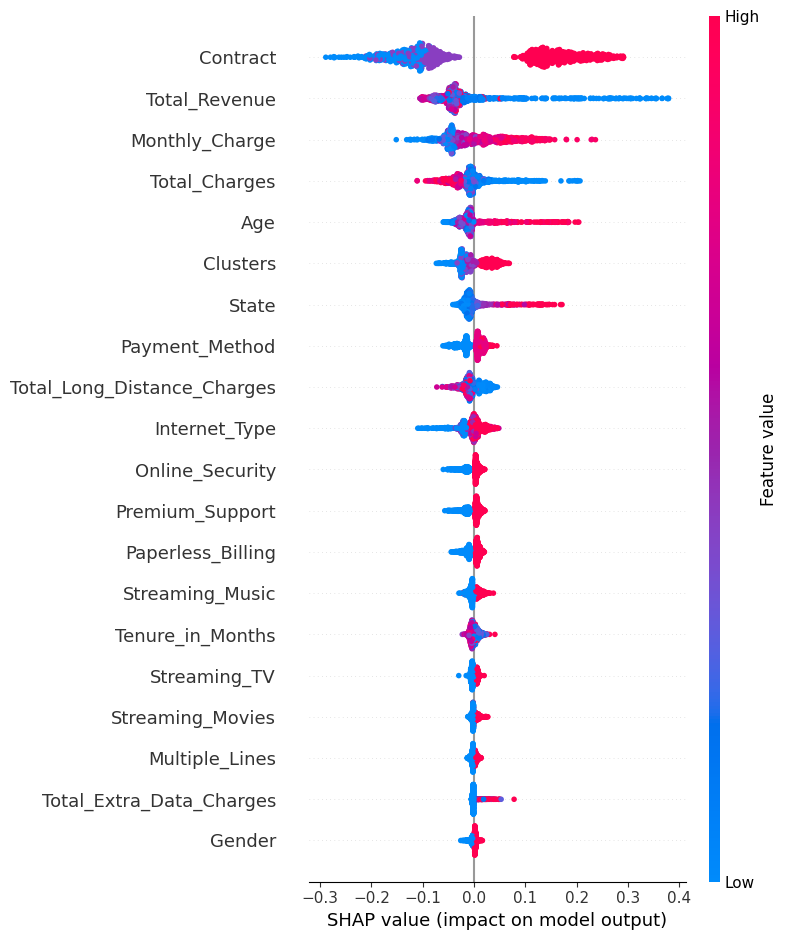

In [11]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_enc)

shap.summary_plot(shap_values, X_test_enc)

### 🚦 Scoring for Joined
- Optimal cutoff is applied (customer predcited score > cutoff = churner)

In [68]:
joined_df = df_labeled[df_labeled['Customer_Status'] == 'Joined'].copy()

joined_df['Clusters'] = joined_df['Clusters'].astype(str)

target = 'Customer_Status'

banished = ['Customer_ID', 'Value_Deal', 'Churn_Reason', 'Churn_Category', 'Internet_Service', 'Monthly_Avg', 'Age_Range']

monetary = ['Monthly_Charge', 'Total_Revenue', 'Total_Charges', 'Total_Long_Distance_Charges', 
            'Total_Extra_Data_Charges', 'Total_Refunds']

to_drop = [target] + banished

X_joined = joined_df.drop(columns=to_drop, errors='ignore')
X_joined_enc = final_encoder.transform(X_joined)
djoined = xgb.DMatrix(X_joined_enc)

# xgb.train hasn't .predict_proba(); .predict() already ranges from 0 to 1
joined_probs = best_model.predict(djoined)

# only flags as churn if % >= optimal threshold
joined_preds = (joined_probs >= best_cutoff).astype(int)

cutoff_pct = best_cutoff * 100
mid = cutoff_pct + (100 - cutoff_pct) / 2

joined_df['Churn_Score'] = (joined_probs * 100).round(2)
joined_df['Predicted_Status'] = joined_preds

cond = [
    (joined_df['Churn_Score'] <= cutoff_pct),
    (joined_df['Churn_Score'] > cutoff_pct) & (joined_df['Churn_Score'] <= mid),
    (joined_df['Churn_Score'] > mid)
]

labels = ['Low', 'Medium', 'High']

joined_df['Risk_Level'] = np.select(cond, labels)

print(f"Optimal cutoff in use: {best_cutoff:.2f}, or {cutoff_pct:.2f} for scoring.")
print(f"Low Risk: <= {cutoff_pct:.2f} %")
print(f"Medium Risk: > {cutoff_pct:.2f} & <= {mid:.2f}")
print(f"High Risk: > {mid:.2f}") 
print("-"*70)
print(joined_df[['Customer_ID', 'Clusters', 'Churn_Score', 'Predicted_Status', 'Risk_Level']].head())
#print("-"*70)
#print(joined_df.groupby(['Clusters', 'Risk_Level'])['Risk_Level'].count())

Optimal cutoff in use: 0.39, or 38.73 for scoring.
Low Risk: <= 38.73 %
Medium Risk: > 38.73 & <= 69.37
High Risk: > 69.37
----------------------------------------------------------------------
    Customer_ID        Clusters  Churn_Score  Predicted_Status Risk_Level
17    93520-GUJ        Loyalist    15.870000                 0        Low
23    57256-BIH  Stable Bundler    76.750000                 1       High
48    72357-MAD  Traditionalist    97.379997                 1       High
98    66612-KAR  Stable Bundler    81.529999                 1       High
104   22119-WES  Stable Bundler    94.059998                 1       High


#### SHAP Table .csv
- To be used in operational PBI Python viz

In [105]:
import shap
import time

start = time.time()
print('Starting script for SHAP df;')

# get only 200 rows for background comparison
bg_sample = shap.sample(X_joined_enc, 200) if len(X_joined_enc) > 200 else X_joined_enc

explainer = shap.TreeExplainer(best_model, 
                               data=bg_sample,
                               model_output="raw",
                               feature_perturbation="interventional")

shap_values_obj = explainer(X_joined_enc)

# float32 halves memory use on new columns
shap_matrix = shap_values_obj.values.astype('float32')

# make features_df from previous encoded df
features_df = X_joined_enc.reset_index(drop=True)

# every column receives a 'shap_' counterpart
shap_cols = [f"shap_{col}" for col in features_df.columns]
shap_df = pd.DataFrame(shap_matrix, columns=shap_cols)
print("SHAP columns created;") 

# base value is the 'default guess', the MEAN
base_val = shap_values_obj.base_values

# if base_val is a list, or a tuple, or whatever shap_matrix is, and its' length == that of features_df
# base_values_col = base_val
# otherwise, base_values_col will be base_val[0] if the latter has length attribute;
# if it doesn't, just base_val 
if isinstance(base_val, (list, tuple, type(shap_matrix))) and len(base_val) == len(features_df):
    base_values_col = base_val
else:
    base_values_col = base_val[0] if hasattr(base_val, "__len__") else base_val

final_export_df = pd.concat([
    pd.Series(joined_df['Customer_ID'].values, name='Customer_ID'),
    pd.Series(joined_df['Churn_Score'].values, name='Churn_Prob'),
    pd.Series(base_values_col, name='shap_base_value', index=features_df.index),
    features_df,
    shap_df
], axis=1)

print(f'⌛ Final table created in {round(time.time() - start,2)} secs!')

final_export_df.to_csv(r"C:/Users/Acer/Downloads/pbi_shap_data.csv", index=False)

Starting script for SHAP df;
SHAP columns created;
⌛ Final table created in 3.32 secs!



## 🥧 Final Plots

#### State Plot of Customers at Risk

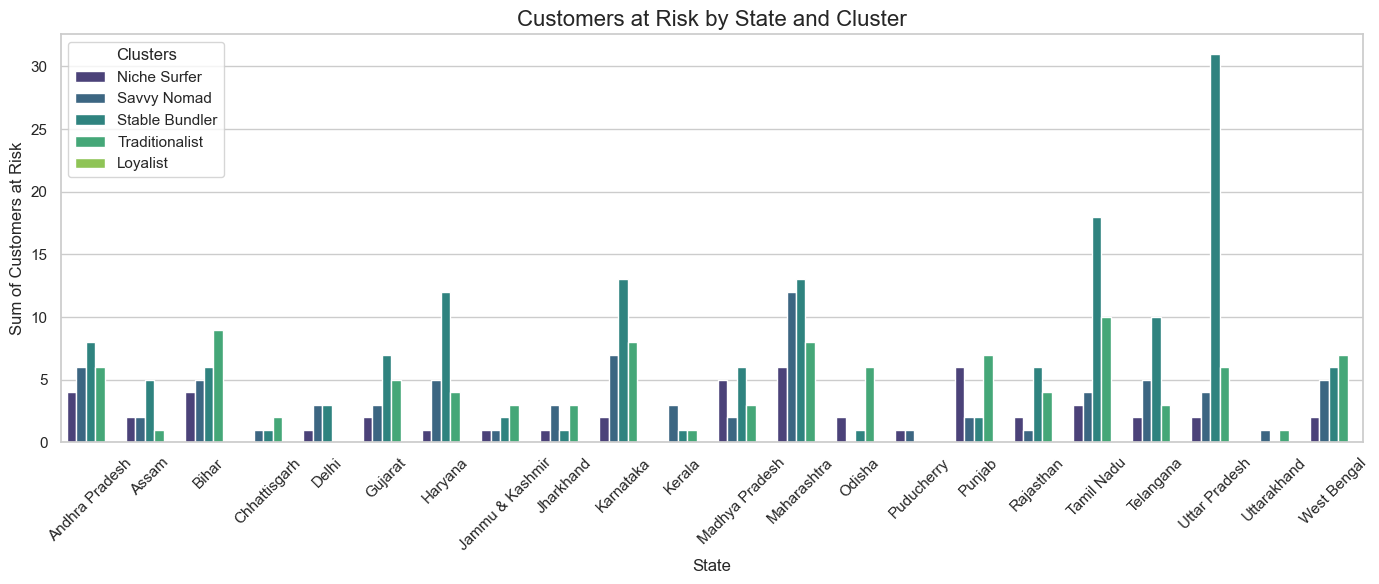

In [109]:
detailed_df = joined_df.groupby(['State', 'Clusters'])['Predicted_Status'].agg(
    Total_Count = 'count',
    Predicted_Count = 'sum',
    Predicted_Rate = 'mean'
).reset_index()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=detailed_df, 
    x='State', 
    y='Predicted_Count', 
    hue='Clusters', 
    palette='viridis'
)

plt.title('Customers at Risk by State and Cluster', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Sum of Customers at Risk', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Clusters')
plt.tight_layout()
plt.savefig(r'C:/Users/Acer/Downloads/State_Risk_Distribution', bbox_inches = 'tight', dpi = 300)
plt.show()
#detailed_df.to_csv("C:/Users/Acer/Downloads/state_predictions.csv")

In [70]:
print(joined_df[joined_df['Predicted_Status'] == 1].groupby('Clusters')['Total_Revenue'].sum())

Clusters
Niche Surfer       6168.53
Savvy Nomad       16318.55
Stable Bundler     9437.59
Traditionalist    10855.02
Name: Total_Revenue, dtype: float64


#### Customer and Revenue Risk summary

In [71]:
import pandas as pd

summary_df = joined_df.groupby('Clusters').agg(
    Total_Customers=('Predicted_Status', 'count'),
    At_Risk=('Predicted_Status', 'sum'),
    Risk_Revenue=('Total_Revenue', lambda x: x[joined_df.loc[x.index, 'Predicted_Status'] == 1].sum())
)

summary_df['Proportion_%'] = (summary_df['Total_Customers'] / summary_df['Total_Customers'].sum() * 100).round(1)
summary_df = summary_df[['Proportion_%', 'Total_Customers',
                         'At_Risk', 'Risk_Revenue']].sort_values(by='Risk_Revenue', ascending=False)

summary_df.style.background_gradient(subset=['At_Risk'], cmap='Oranges')\
                .bar(subset=['Risk_Revenue'], color='#EF553B')\
                .format({'Risk_Revenue': '${:,.2f}', 'Proportion_%': '{:.1f}%'})

,Proportion_%,Total_Customers,At_Risk,Risk_Revenue
Clusters,,,,
Savvy Nomad,20.7%,85,76,"$16,318.55"
Traditionalist,25.3%,104,97,"$10,855.02"
Stable Bundler,40.6%,167,152,"$9,437.59"
Niche Surfer,12.4%,51,49,"$6,168.53"
Loyalist,1.0%,4,0,$0.00


#### Finished Inclinations

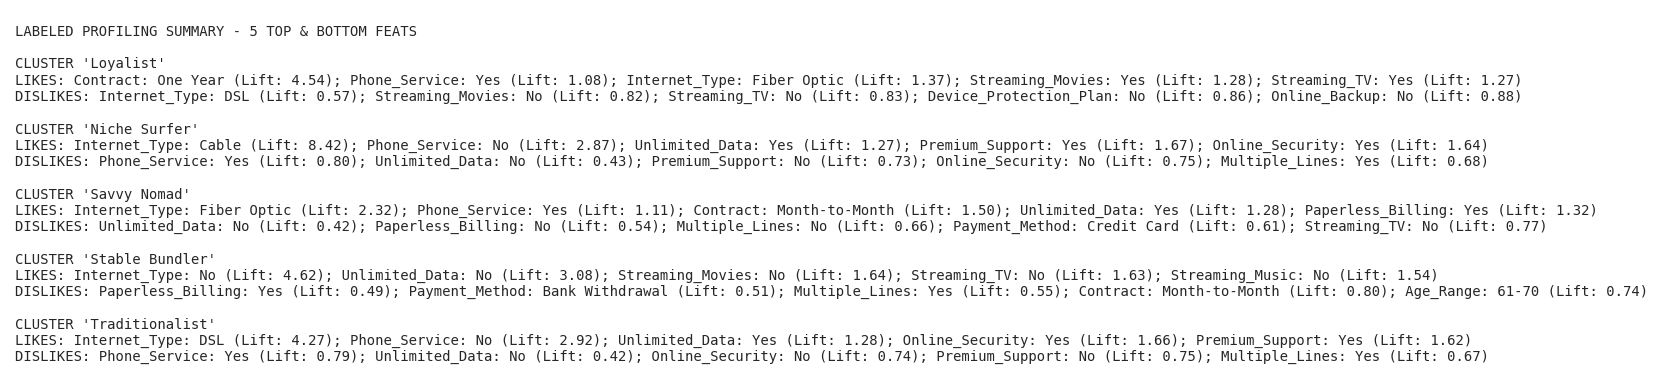

In [90]:
from scipy.stats import chi2_contingency

def robust_cluster_profiling(df, cluster_col='Clusters', alpha=1.0, min_freq=0.1):
    
    banished = ['Customer_ID', 'Value_Deal', 'Customer_Status', 'Churn_Reason', 
                'Churn_Category', 'State', 'Internet_Service', 'Tenure_Range', 'RLV']

    categoricals = df_labeled.select_dtypes(exclude=[np.number]).columns
    features = [c for c in categoricals if c not in banished and c != cluster_col ]
    
    results = []
    global_total = len(df)

    for feature in features:

        # chi-square as first filter (p < 0.05)
        ct = pd.crosstab(df[cluster_col], df[feature]) 
        chi2, p, dof, ex = chi2_contingency(ct)

        if p >= 0.05:
            continue

        # index is the category of the column, value is the frequency
        global_counts = df[feature].value_counts()
        
        for cluster in df[cluster_col].unique():
            
            # mask for matching cluster name
            cluster_df = df[df[cluster_col] == cluster]

            # n = (a + b); total length of cluster
            n = len(cluster_df)
            cluster_counts = cluster_df[feature].value_counts()

            for val in global_counts.index:
                
                # x = a; customers WITHIN cluster, WITH category
                x = cluster_counts.get(val, 0)

                # frequency of certain category of certain column div by total row count of that cluster 
                freq = x / n
                
                # 'continue' skips if False
                if freq < min_freq:
                    continue

                # Laplace adds alpha for a smoothed possibility
                # (a + alpha) / (a + b + alpha * 2)
                # smoothed % of WITHIN cluster WITH cat?
                p_cluster_smooth = (x + alpha) / (n + alpha * 2)

                # x_out = everyone OUT of cluster WITH category
                x_out = global_counts[val] - x

                # n_out = ALL of those OUTSIDE of cluster
                n_out = global_total - n

                # smoothed % of OUTSIDE cluster WITH cat?
                p_out_smooth = (x_out + alpha) / (n_out + alpha * 2)

                # log scale of diff between smoothed %
                log_odds = np.log(p_cluster_smooth / (1 - p_cluster_smooth)
                                 ) - np.log(p_out_smooth / (1 - p_out_smooth))

                # Lift = how many times more/less it appears in that cluster compared to absolute GLOBAL
                lift = freq / (global_counts[val] / global_total)

                results.append({
                    'Cluster': cluster,
                    'Feature': f"{feature}: {val}",
                    'Frequency': round(freq, 3),
                    'Log_Odds_Smooth': round(log_odds, 3),
                    'Lift': round(lift, 3)
                })

    return pd.DataFrame(results).sort_values(['Cluster', 'Log_Odds_Smooth'], ascending=[True, False])

profile_df = robust_cluster_profiling(df_labeled)

# only significant impacts
log_cutoff = 0.5

# only categories with x1.5+ freq
lift_cutoff = 1.5

fig, ax = plt.subplots(figsize=(12, 4)) 
ax.axis('off')

chosen_num = 5
text_output = f"LABELED PROFILING SUMMARY - {chosen_num} TOP & BOTTOM FEATS\n"

for cluster in sorted(profile_df['Cluster'].unique()):
    cluster_mask = profile_df[profile_df['Cluster'] == cluster]

    likes_df = cluster_mask[cluster_mask['Log_Odds_Smooth'] > 0]
    dislikes_df = cluster_mask[cluster_mask['Log_Odds_Smooth'] < 0]

    top_rows = likes_df.nlargest(chosen_num, 'Log_Odds_Smooth')
    top_feats = [f"{row['Feature']} (Lift: {row['Lift']:.2f})" for _, row in top_rows.iterrows()]
    
    bottom_rows = dislikes_df.nsmallest(chosen_num, 'Log_Odds_Smooth')
    bottom_feats = [f"{row['Feature']} (Lift: {row['Lift']:.2f})" for _, row in bottom_rows.iterrows()]

    text_output += f"\nCLUSTER '{cluster}'\n" 
    text_output += f"LIKES: {'; '.join(top_feats)}\n"
    text_output += f"DISLIKES: {'; '.join(bottom_feats)}\n"

plt.text(0.01, 0.95, text_output, 
         family='monospace', 
         fontsize=10, 
         verticalalignment='top', 
         transform=ax.transAxes)

plt.tight_layout()
plt.savefig(r'C:/Users/Acer/Downloads/Profiling_Summary_Labeled.png', dpi=300, bbox_inches='tight', facecolor= 'white')